In [7]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../../../../data_capsule/ROUND_2/prices_round_2_day_-1.csv", sep=";")

# print(df.columns)
# print(df.head())


osmium = df[df["product"] == "ASH_COATED_OSMIUM"].copy()
osmium = osmium.sort_values("timestamp")

osmium = osmium[
    (osmium["bid_price_1"] > 0) &
    (osmium["ask_price_1"] > 0)
]
osmium["mid"] = (osmium["bid_price_1"] + osmium["ask_price_1"]) / 2

osmium_sampled = osmium.iloc[::20]


In [8]:
# ===== EMA =====
class EMAFilter:
    def __init__(self, alpha=0.1):
        self.alpha = alpha
        self.value = None

    def update(self, price):
        if self.value is None:
            self.value = price
        else:
            self.value = self.alpha * price + (1 - self.alpha) * self.value
        return self.value


# ===== DOUBLE EMA =====
class DoubleEMA:
    def __init__(self, alpha=0.2):
        self.ema1 = EMAFilter(alpha)
        self.ema2 = EMAFilter(alpha)

    def update(self, price):
        e1 = self.ema1.update(price)
        e2 = self.ema2.update(e1)
        return 2 * e1 - e2

In [9]:
def evaluate_filter(filter_class, alpha):
    filt = filter_class(alpha)

    filtered = []
    for p in osmium_sampled["mid"]:
        filtered.append(filt.update(p))

    df = osmium_sampled.copy()
    df["filtered"] = filtered

    # deviation
    df["dev"] = df["mid"] - df["filtered"]

    # z-score
    rolling_std = df["dev"].rolling(100).std()
    df["z"] = df["dev"] / rolling_std

    # future return
    import numpy as np
    price = df["mid"].values
    z = df["z"].values
    fut_ret = np.roll(price, -1) - price

    mask = ~np.isnan(z)
    corr = np.corrcoef(z[mask][:-1], fut_ret[mask][:-1])[0,1]

    # signal count
    signal_count = (abs(df["z"]) > 2).sum()

    return corr, signal_count, df

In [10]:
alphas = [0.1, 0.15, 0.2]

print("=== EMA ===")
for a in alphas:
    corr, signals, _ = evaluate_filter(EMAFilter, a)
    print(f"alpha={a:.2f} → corr={corr:.4f}, signals={signals}")

print("\n=== DOUBLE EMA ===")
for a in alphas:
    corr, signals, _ = evaluate_filter(DoubleEMA, a)
    print(f"alpha={a:.2f} → corr={corr:.4f}, signals={signals}")

=== EMA ===
alpha=0.10 → corr=-0.2732, signals=22
alpha=0.15 → corr=-0.2832, signals=17
alpha=0.20 → corr=-0.2940, signals=18

=== DOUBLE EMA ===
alpha=0.10 → corr=-0.2567, signals=22
alpha=0.15 → corr=-0.2730, signals=20
alpha=0.20 → corr=-0.2884, signals=18


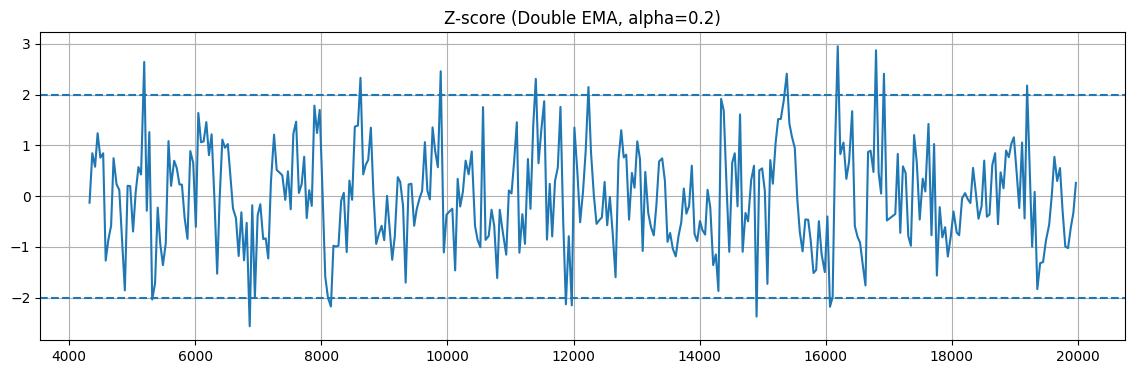

In [11]:
best_alpha = 0.2
_, _, df = evaluate_filter(DoubleEMA, best_alpha)

import matplotlib.pyplot as plt

plt.figure(figsize=(14,4))
plt.plot(df["z"])
plt.axhline(2, linestyle="--")
plt.axhline(-2, linestyle="--")
plt.title(f"Z-score (Double EMA, alpha={best_alpha})")
plt.grid()
plt.show()